# Notebook 02 — Descriptive Statistics

**Dissertation:** *Beyond Money: Who Responds to Intergenerational Appeals for Sustainable Cooperation?*

This notebook consolidates the project's participant-level and decision-round-level descriptive analysis into a single reference document.

1. Setup and Global Configuration
2. Data Loading and Construction of the Participant-Level Analytical Dataset
3. **Table 1. Sample Characteristics** (Gender, Ethnicity, Education, and Age)
4. **Table 2. Treatment Allocation and Cell Size Balance**
5. Randomisation Balance Assessment (Covariate Equivalence Across Treatment Conditions)
6. Green Choice Behaviour by Treatment Condition
   - **Table 3a.** Round-Level Green Choice Rates
   - **Table 3b.** Participant-Level Green Choice Rates
   - **Figure 1.** Participant-Level Green Choice Rates Across Treatment Conditions
7. **Figure 2.** Extraction Trajectories Across Rounds by Treatment Condition
8. Descriptive Analysis of Moderator Variables
    - **Table 4.** Descriptive Statistics for Moderator Variables
    - **Figure 3.** Distribution of Ideological Self-Placement
    - **Figure 4.** Participant-Level Distributions of Political Ideology, Legacy Concern, and Environmental Concern
9. Multilevel Data Structure (Rounds Nested Within Participants Within Sessions)
10. Prolific-Only Electoral Variables (Robustness Check Descriptives)
11. Missing Data Audit (Three-Stage Attrition and Analytical Sample Completeness)
12. Export of Derived Tables and Participant-Level Datasets

All inputs are the analytic CSVs written by Notebook 01 (`data/mturk_clean.csv`, `data/prolific_clean.csv`).

## 1 · Setup & Global Configuration

In [1]:
# Cell 1: Imports and global settings
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, chisquare, f_oneway

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 150})

os.makedirs('outputs/tables',  exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

PLATFORMS = {'mturk': 'Study 1 (MTurk)', 'prolific': 'Study 2 (Prolific)'}

# Canonical treatment labels and integer coding (Notebook 01, TREATMENT_STR_MAP).
TREAT_MAP   = {1: 'IT&GI', 2: 'IT', 3: 'GI', 4: 'NIT&NGI'}
TREAT_ORDER = ['IT&GI', 'IT', 'GI', 'NIT&NGI']

GENDER_DUMMY_LABELS = {'Gender_1': 'Male', 'Gender_2': 'Female', 'Gender_3': 'Other'}
ETHN_DUMMY_LABELS = {
    'Ethn_1': 'White',
    'Ethn_2': 'Black',
    'Ethn_3': 'Hispanic or Latino/Latina',
    'Ethn_4': 'Asian',
    'Ethn_5': 'Mixed',
}
EDU_MAP = {
    1: 'Less than high school (Grade 11 or less)',
    2: 'High School Diploma (including GED)',
    3: 'Some college',
    4: 'Associate degree (2 years) or specialized technical training',
    5: "Bachelor's degree",
    6: 'Some graduate training',
    7: 'Graduate/professional degree or higher',
}
# Threshold used for the binary "Bachelor's degree or higher" indicator
# (Table 1 and the randomisation balance check both reference this cutoff).
BACHELORS_PLUS_CUTOFF = 5

print('Environment ready.')

Environment ready.


## 2 · Data Loading & Participant-Level Analytic Frame

Round-level analytic CSVs are loaded and a participant-level frame is derived by taking each participant's first observation. Demographics, moderators, treatment, and session identifiers are time-invariant within participant under the between-subjects design, so `first()` is a lossless collapse for these fields. `extract_green_choice` is additionally summarised as a per-participant mean — the proportion of the 10 decision rounds in which that participant selected response category 2 — for the participant-level outcome comparison in Section 6 and the multilevel-structure summary in Section 9; round-level statistics (Table 3, Figure 1) use the full round-level frame directly.

In [2]:
# Cell 2: Load analytic datasets and construct the participant-level frame
df_mt = pd.read_csv('data/mturk_clean.csv')
df_pr = pd.read_csv('data/prolific_clean.csv')

for df, label in [(df_mt, 'MTurk'), (df_pr, 'Prolific')]:
    df['study']         = label
    df['treatment_str'] = df['treatment'].map(TREAT_MAP)

# Participant-level demographic/moderator frame
demo_mt = df_mt.groupby('participantcode').first().reset_index()
demo_pr = df_pr.groupby('participantcode').first().reset_index()

# Participant-level extract_green_choice rate (proportion of rounds = category 2 of 3)
demo_mt = demo_mt.merge(df_mt.groupby('participantcode')['extract_green_choice'].mean().rename('extract_green_choice_rate'),
                         on='participantcode', how='left')
demo_pr = demo_pr.merge(df_pr.groupby('participantcode')['extract_green_choice'].mean().rename('extract_green_choice_rate'),
                         on='participantcode', how='left')

print(f'Analytic N (participants) — MTurk: {len(demo_mt):,} | Prolific: {len(demo_pr):,}')
print(f'Analytic N (rounds)       — MTurk: {len(df_mt):,} | Prolific: {len(df_pr):,}')

Analytic N (participants) — MTurk: 1,022 | Prolific: 1,017
Analytic N (rounds)       — MTurk: 10,220 | Prolific: 10,170


## 3 · Table 1 — Sample Composition

- **Gender** — `Gender_1`/`Gender_2`/`Gender_3` (Male / Female / Other).
- **Ethnicity** — `Ethn_1..Ethn_5` (White/Majority, Black, Hispanic/Latino, Asian, Other).
- **Education** — seven categories read directly from `education` (see `EDU_MAP`, Section 1).
- **Age** — continuous, M ± SD.
- **Supplementary indicators** — Bachelor's degree or higher (`education ≥ 5`, proportion ± SD) and number of children (`prole`, oTree `IntegerField` 0–10, "How many children do you have?", M ± SD in the same row style as Age).

Ideology (`liberal`), party identification (`political_orientation`), and the composite attitude scales are moderator variables and are reported in Section 8, not here — consistent with their treatment as continuous moderators, not demographic descriptors, in the primary models.

In [3]:
# Cell 3: Table 1 — Sample composition
def dummy_prop_sd(series):
    """Proportion and SD for a 0/1 indicator. pandas .mean()/.std() skip NaN,
    so missing values are correctly excluded from the denominator."""
    s = series.astype(float)
    return f'{s.mean():.3f} ({s.std(ddof=1):.3f})'

def cat_prop_sd(series, value):
    """Proportion and SD of a single category, derived on the fly from a
    categorical column. Missing values in `series` stay missing in the
    indicator rather than counting as 0."""
    indicator = (series == value).astype(float).where(series.notna())
    return dummy_prop_sd(indicator)

def mean_sd(series):
    return f'{series.mean():.1f} ({series.std(ddof=1):.1f})'

rows = []
rows.append({'Variable': 'N participants',
             'Study 1 (MTurk)': str(len(demo_mt)), 'Study 2 (Prolific)': str(len(demo_pr))})
rows.append({'Variable': 'Age M (SD)',
             'Study 1 (MTurk)': mean_sd(demo_mt['age']), 'Study 2 (Prolific)': mean_sd(demo_pr['age'])})

for col, label in GENDER_DUMMY_LABELS.items():
    rows.append({'Variable': f'Gender: {label}',
                 'Study 1 (MTurk)':    dummy_prop_sd(demo_mt[col]) if col in demo_mt.columns else '—',
                 'Study 2 (Prolific)': dummy_prop_sd(demo_pr[col]) if col in demo_pr.columns else '—'})

for col, label in ETHN_DUMMY_LABELS.items():
    rows.append({'Variable': f'Ethnicity: {label}',
                 'Study 1 (MTurk)':    dummy_prop_sd(demo_mt[col]) if col in demo_mt.columns else '—',
                 'Study 2 (Prolific)': dummy_prop_sd(demo_pr[col]) if col in demo_pr.columns else '—'})

for level, label in EDU_MAP.items():
    rows.append({'Variable': f'Education: {label}',
                 'Study 1 (MTurk)':    cat_prop_sd(demo_mt['education'], level) if 'education' in demo_mt.columns else '—',
                 'Study 2 (Prolific)': cat_prop_sd(demo_pr['education'], level) if 'education' in demo_pr.columns else '—'})

# Supplementary indicators (participant-level)
for df_demo in (demo_mt, demo_pr):
    df_demo['bachelors_plus'] = (df_demo['education'] >= BACHELORS_PLUS_CUTOFF).astype(float).where(df_demo['education'].notna())

rows.append({'Variable': f"Education: Bachelor's degree or higher (≥ level {BACHELORS_PLUS_CUTOFF})",
             'Study 1 (MTurk)':    dummy_prop_sd(demo_mt['bachelors_plus']),
             'Study 2 (Prolific)': dummy_prop_sd(demo_pr['bachelors_plus'])})
# prole = oTree IntegerField(min=0, max=10), "How many children do you have?"
rows.append({'Variable': 'Number of children, M (SD) [prole, 0–10]',
             'Study 1 (MTurk)':    mean_sd(demo_mt['prole']) if 'prole' in demo_mt.columns else '—',
             'Study 2 (Prolific)': mean_sd(demo_pr['prole']) if 'prole' in demo_pr.columns else '—'})

table1 = pd.DataFrame(rows).set_index('Variable')
table1.to_csv('outputs/tables/table1_sample_composition.csv')

print('Table 1 — Sample Composition')
print('(Proportion (SD) unless stated otherwise)\n')
print(table1.to_string())

Table 1 — Sample Composition
(Proportion (SD) unless stated otherwise)

                                                                        Study 1 (MTurk) Study 2 (Prolific)
Variable                                                                                                  
N participants                                                                     1022               1017
Age M (SD)                                                                  40.4 (12.0)        36.3 (13.0)
Gender: Male                                                              0.520 (0.500)      0.480 (0.500)
Gender: Female                                                            0.478 (0.500)      0.499 (0.500)
Gender: Other                                                             0.002 (0.044)      0.022 (0.146)
Ethnicity: White                                                          0.760 (0.427)      0.699 (0.459)
Ethnicity: Black                                                        

## 4 · Table 2 — Treatment Allocation

Participant counts and cell percentages per condition, with a chi-square goodness-of-fit test of equal allocation across the four conditions within each study (H0: 25% per cell). Sessions are the unit of randomisation (up to four participants per session), so minor imbalance is expected from integer constraints on session-to-condition allocation; the test flags allocation that departs from this expectation by more than chance.

The goodness-of-fit test below (`scipy.stats.chisquare`) is the correct test for this hypothesis.

In [4]:
# Cell 4: Table 2 — Treatment cell counts, percentages, and goodness-of-fit test
balance_rows = []
for label, demo in [('MTurk', demo_mt), ('Prolific', demo_pr)]:
    counts = demo['treatment_str'].value_counts().reindex(TREAT_ORDER, fill_value=0)
    pct    = (counts / counts.sum() * 100).round(1)
    chi2, p = chisquare(counts)  # default: equal expected frequencies across the 4 cells

    row = {f'{c} (n)': int(counts[c]) for c in TREAT_ORDER}
    row.update({f'{c} (%)': pct[c] for c in TREAT_ORDER})
    row['N total'] = int(counts.sum())
    row['χ² (goodness-of-fit)'] = round(chi2, 3)
    row['p'] = round(p, 3)
    balance_rows.append(pd.Series(row, name=label))

table2 = pd.DataFrame(balance_rows)
table2.index.name = 'Study'
table2.to_csv('outputs/tables/table2_treatment_allocation.csv')
print('Table 2 — Treatment Allocation')
print(table2.to_string())

Table 2 — Treatment Allocation
          IT&GI (n)   IT (n)   GI (n)  NIT&NGI (n)  IT&GI (%)  IT (%)  GI (%)  NIT&NGI (%)   N total  χ² (goodness-of-fit)      p
Study                                                                                                                            
MTurk      257.0000 240.0000 251.0000     274.0000    25.1000 23.5000 24.6000      26.8000 1022.0000                2.3680 0.5000
Prolific   257.0000 229.0000 290.0000     241.0000    25.3000 22.5000 28.5000      23.7000 1017.0000                8.2550 0.0410


## 5 · Randomisation Balance — Covariate Equivalence Across Conditions

Independent of cell-size balance (Table 2), successful randomisation requires pre-treatment covariates to be equivalent across the four conditions. Continuous covariates are tested with one-way ANOVA; categorical covariates with a χ² test of independence. A significant result would indicate a covariate imbalance to investigate; none is expected to be actioned given session-level random assignment was confirmed in the study pre-registration.

In [5]:
# Cell 5: Covariate balance across treatment conditions
def balance_check(demo, label):
    print(f"\n{'='*60}")
    print(f'Balance Check — {label}')
    print(f"{'='*60}")
    cond_groups = {c: demo[demo['treatment_str'] == c] for c in TREAT_ORDER if c in demo['treatment_str'].values}

    continuous_vars = [
        ('age',                  'Age'),
        ('political_orientation','Party identification (1–8, continuous)'),
        ('env_concern_z',        'Environmental concern (z)'),
        ('legacy_z',             'Legacy concern (z)'),
    ]
    print('\nContinuous covariates — one-way ANOVA:')
    for col, vname in continuous_vars:
        if col not in demo.columns or demo[col].notna().sum() == 0:
            continue
        groups = [g[col].dropna().values for g in cond_groups.values()]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) < 2:
            continue
        F, pval = f_oneway(*groups)
        flag = '  *** CHECK' if pval < 0.05 else ''
        print(f'  {vname:<45}  F = {F:6.3f}  p = {pval:.4f}{flag}')

    print('\nCategorical covariates — χ² test of independence:')

    # Gender (3-category) and Ethnicity (5-category) via their validated dummy sets
    for dummy_cols, vname in [(list(GENDER_DUMMY_LABELS), 'Gender (3-category)'),
                               (list(ETHN_DUMMY_LABELS),   'Ethnicity (5-category)')]:
        present = [c for c in dummy_cols if c in demo.columns]
        if not present:
            continue
        cat_series = demo[present].idxmax(axis=1).where(demo[present].sum(axis=1) > 0)
        ct = pd.crosstab(cat_series, demo['treatment_str'])
        chi2, pval, dof, _ = chi2_contingency(ct)
        flag = '  *** CHECK' if pval < 0.05 else ''
        print(f'  {vname:<45}  χ²({dof}) = {chi2:6.3f}  p = {pval:.4f}{flag}')

    # Education ≥ Bachelor's (binary)
    if 'education' in demo.columns:
        ct = pd.crosstab(demo['bachelors_plus'], demo['treatment_str'])
        chi2, pval, dof, _ = chi2_contingency(ct)
        flag = '  *** CHECK' if pval < 0.05 else ''
        edu_label = "Education >= Bachelor's (binary)"
        print(f'  {edu_label:<45}  χ²({dof}) = {chi2:6.3f}  p = {pval:.4f}{flag}')

balance_check(demo_mt, 'Study 1 (MTurk)')
balance_check(demo_pr, 'Study 2 (Prolific)')


Balance Check — Study 1 (MTurk)

Continuous covariates — one-way ANOVA:
  Age                                            F =  0.963  p = 0.4096
  Party identification (1–8, continuous)         F =  0.643  p = 0.5874

Categorical covariates — χ² test of independence:
  Gender (3-category)                            χ²(6) =  4.134  p = 0.6586
  Ethnicity (5-category)                         χ²(12) =  9.387  p = 0.6696
  Education >= Bachelor's (binary)               χ²(3) =  0.942  p = 0.8154

Balance Check — Study 2 (Prolific)

Continuous covariates — one-way ANOVA:
  Age                                            F =  0.510  p = 0.6756
  Party identification (1–8, continuous)         F =  2.510  p = 0.0574
  Environmental concern (z)                      F =  0.383  p = 0.7650
  Legacy concern (z)                             F =  1.274  p = 0.2820

Categorical covariates — χ² test of independence:
  Gender (3-category)                            χ²(6) =  8.479  p = 0.2051
  Ethnicity 

## 6 · Table 3 — Outcome Variable (`extract_green_choice`) by Treatment

`extract_green_choice` is the project's focal dependent variable: a 0/1 indicator for whether a participant selected response category 2 of the three-category `extraction` choice in a given round. Two complementary levels of aggregation are reported:

- **Round-level** (Table 3a) — mean, SD, and N across all decision-rounds within condition; this is the level at which the linear-probability multilevel model operates.
- **Participant-level** (Table 3b / Figure 2) — each participant's own rate across their 10 rounds, averaged within condition with 95% CI error bars; this gives a between-person view of the same effect, free of within-person round-to-round correlation.

In [6]:
# Cell 6a: Table 3a — extract_green_choice by treatment, round level
def extraction_table_round(df, label):
    tbl = (
        df.groupby('treatment_str')['extract_green_choice']
        .agg(Mean='mean', SD='std', N_decision='count')
        .reindex(TREAT_ORDER)
        .round(3)
    )
    tbl.index.name = label
    return tbl

table3a_mt = extraction_table_round(df_mt, 'MTurk')
table3a_pr = extraction_table_round(df_pr, 'Prolific')
table3a    = pd.concat([table3a_mt, table3a_pr], keys=['Study 1 (MTurk)', 'Study 2 (Prolific)'])
table3a.to_csv('outputs/tables/table3a_extraction_by_treatment_roundlevel.csv')
print('Table 3a — Mean Green Choice Rate by Treatment Condition (Decision-Round Level)')
print(table3a.to_string())

Table 3a — Mean Green Choice Rate by Treatment Condition (Decision-Round Level)
                             Mean     SD  N_decision
                   MTurk                            
Study 1 (MTurk)    IT&GI   0.3480 0.4770        2570
                   IT      0.2680 0.4430        2400
                   GI      0.2900 0.4540        2510
                   NIT&NGI 0.1530 0.3600        2740
Study 2 (Prolific) IT&GI   0.3650 0.4820        2570
                   IT      0.3130 0.4640        2290
                   GI      0.3210 0.4670        2900
                   NIT&NGI 0.2070 0.4050        2410


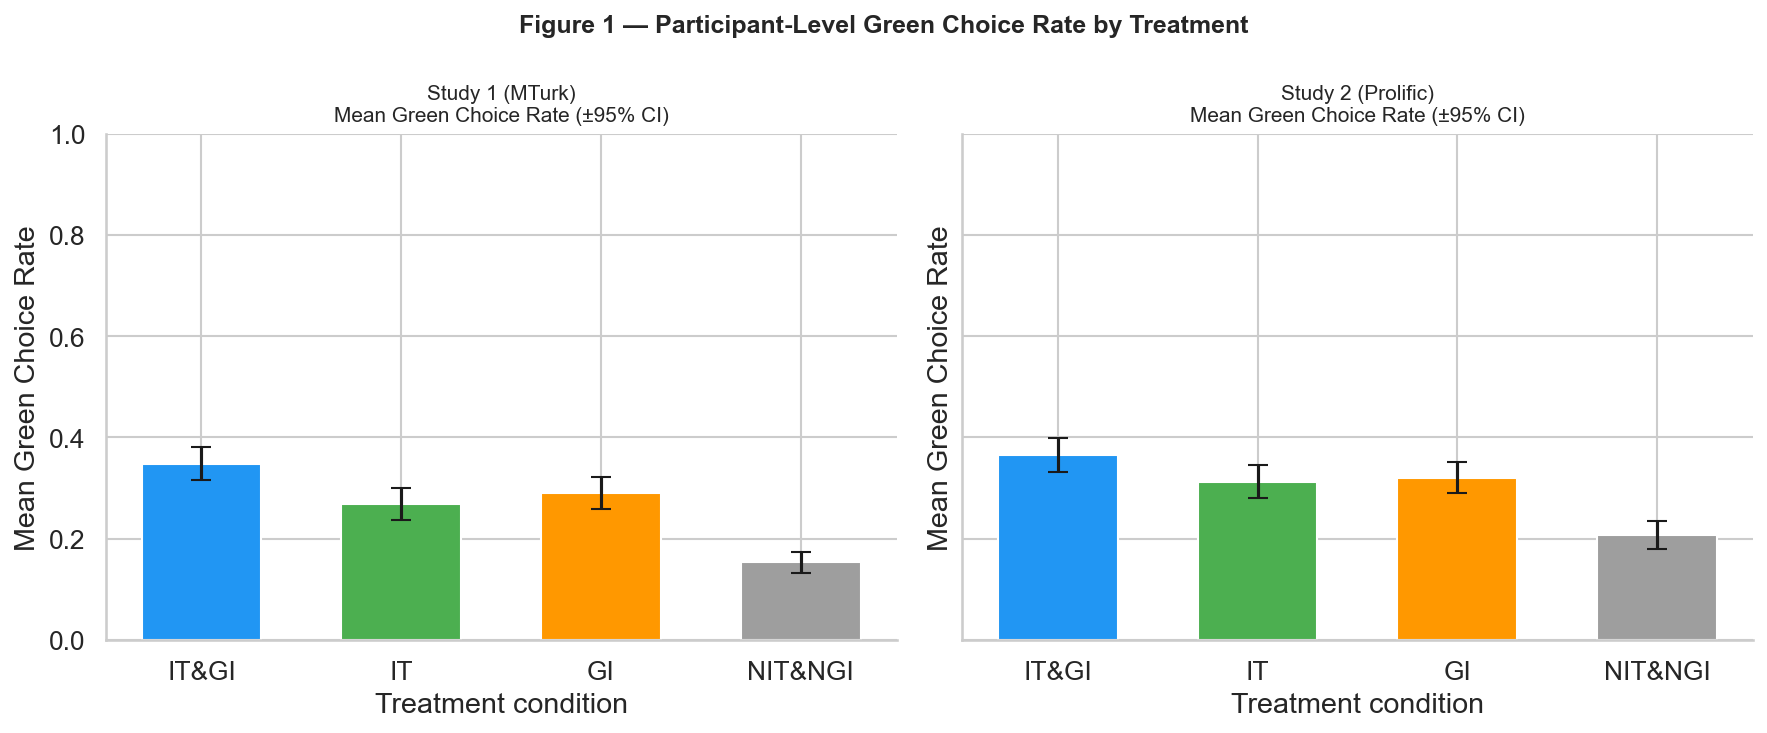


Table 3b — Table 3b — Participant-Level Green Choice Rate by Treatment
                                     mean    std  count
                   Study 1 (MTurk)                     
Study 1 (MTurk)    IT&GI           0.3482 0.2687    257
                   IT              0.2675 0.2501    240
                   GI              0.2900 0.2552    251
                   NIT&NGI         0.1533 0.1708    274
Study 2 (Prolific) IT&GI           0.3650 0.2776    257
                   IT              0.3127 0.2539    229
                   GI              0.3207 0.2721    290
                   NIT&NGI         0.2071 0.2240    241


In [7]:
# Cell 6b: Table 3b / Figure 2 — participant-level extract_green_choice rate by treatment
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
COND_COLORS = {'IT&GI': '#2196F3', 'IT': '#4CAF50', 'GI': '#FF9800', 'NIT&NGI': '#9E9E9E'}

table3b_parts = []
for ax, (demo, plabel) in zip(axes, [(demo_mt, 'Study 1 (MTurk)'), (demo_pr, 'Study 2 (Prolific)')]):
    grp = (demo.groupby('treatment_str')['extract_green_choice_rate']
               .agg(['mean', 'std', 'count'])
               .reindex(TREAT_ORDER))
    grp['se'] = grp['std'] / np.sqrt(grp['count'])
    grp.index.name = plabel
    table3b_parts.append(grp[['mean', 'std', 'count']].round(4))

    ax.bar(TREAT_ORDER, grp['mean'], yerr=grp['se'] * 1.96, capsize=5,
           color=[COND_COLORS[c] for c in TREAT_ORDER], edgecolor='white', width=0.6)
    ax.set_title(f'{plabel}\nMean Green Choice Rate (±95% CI)', fontsize=10)
    ax.set_xlabel('Treatment condition')
    ax.set_ylabel('Mean Green Choice Rate')
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Figure 1 — Participant-Level Green Choice Rate by Treatment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/figure1_Participant-Level Green Choice Rate by Treatment.png', dpi=200, bbox_inches='tight')
plt.show()

table3b = pd.concat(table3b_parts, keys=['Study 1 (MTurk)', 'Study 2 (Prolific)'])
table3b.to_csv('outputs/tables/table3b_Participant-Level Green Choice Rate by Treatment.csv')
print('\nTable 3b — Table 3b — Participant-Level Green Choice Rate by Treatment')
print(table3b.to_string())

## 7 · Figure 2 — Extraction Trajectory by Round and Treatment

Round-by-round trajectory of the mean `extract_green_choice` rate across the 10 decision rounds, by condition, both studies on shared axes for direct comparability. Shaded bands are ±1 SE. This documents whether an end-game decline is present — relevant to whether `round` should enter the multilevel model non-linearly.

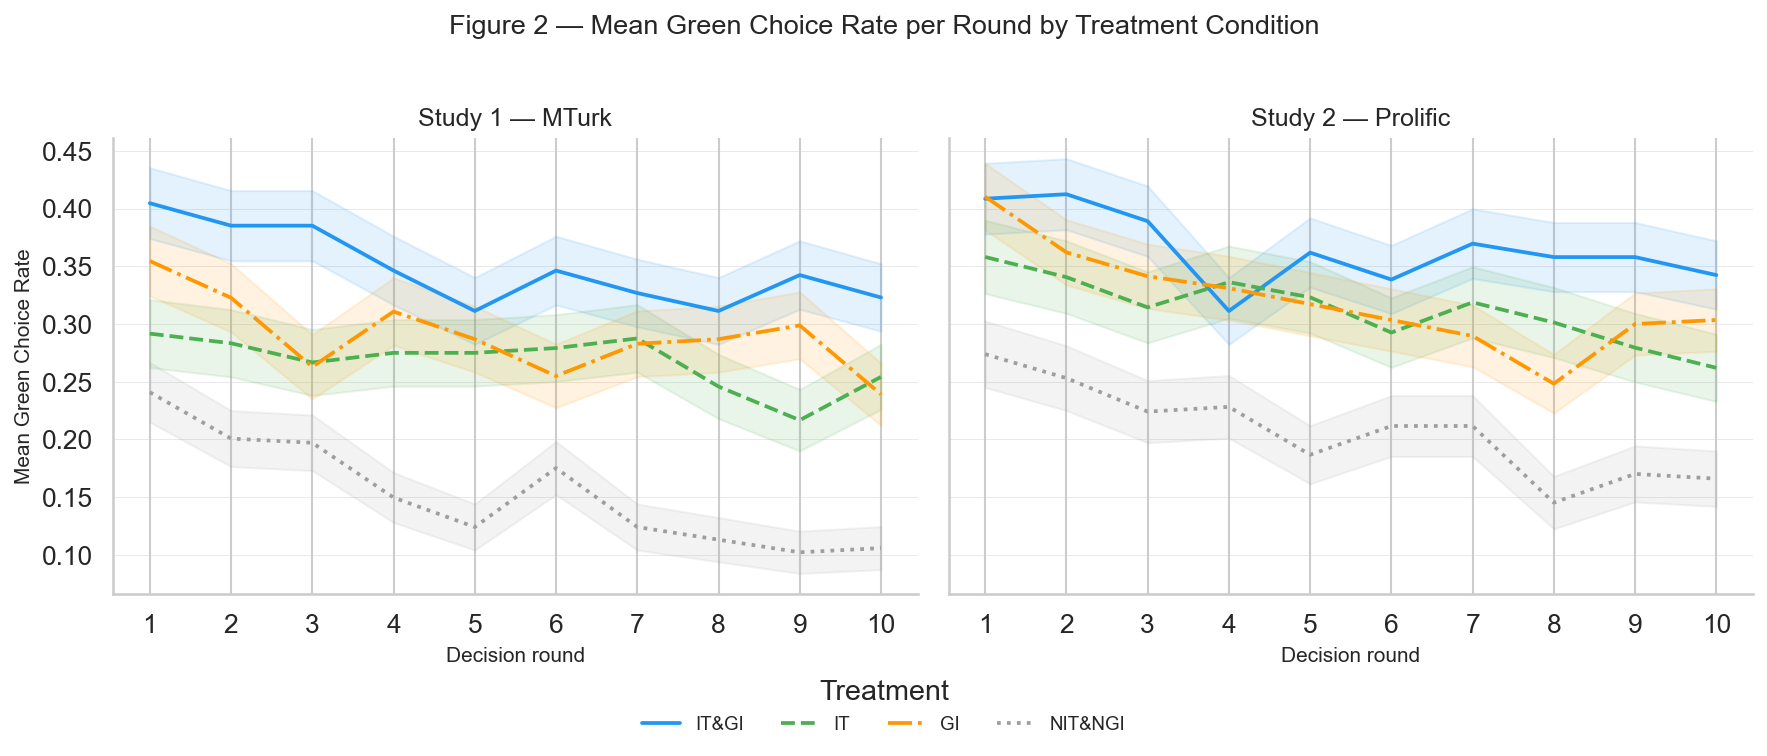

Figure 2 saved to outputs/figures/figure2_green_choice_rate_by_round.png


In [8]:
# Cell 7: Figure 1 — extract_green_choice trajectory by round and treatment
LSTYLE = {'IT&GI': '-', 'IT': '--', 'GI': '-.', 'NIT&NGI': ':'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (df, label) in zip(axes, [(df_mt, 'Study 1 — MTurk'), (df_pr, 'Study 2 — Prolific')]):
    for treat in TREAT_ORDER:
        sub = df[df['treatment_str'] == treat]
        grp = sub.groupby('round')['extract_green_choice']
        m, se = grp.mean(), grp.sem()
        ax.plot(m.index, m.values, color=COND_COLORS[treat], linestyle=LSTYLE[treat],
                linewidth=1.8, label=treat)
        ax.fill_between(m.index, m - se, m + se, color=COND_COLORS[treat], alpha=0.12)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Decision round', fontsize=10)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Mean Green Choice Rate', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Treatment', loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

fig.suptitle('Figure 2 — Mean Green Choice Rate per Round by Treatment Condition', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/figure2_green_choice_rate_by_round.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved to outputs/figures/figure2_green_choice_rate_by_round.png')

## 8 · Moderator Variable Descriptives

Ideology (`liberal`, 1–7), party identification (`political_orientation`, 1–8, code 8 = Other party per Notebook 01), and the study-specific moderators (legacy concern, environmental concern, risk attitude, short/long-reward preference) are summarised at participant level. `political_orientation` is treated as continuous in all models (`party_id_z`); the categorical Liberal/Moderate/Conservative breakdown below is descriptive only and is not used in any regression.

In [9]:
# Cell 8a: Moderator descriptives — numeric summary, participant level
def mod_desc(demo, cols, label):
    rows = []
    for col in cols:
        if col in demo.columns and demo[col].notna().sum() > 0:
            rows.append({
                'Variable': col,
                'N':    demo[col].notna().sum(),
                'Mean': round(demo[col].mean(), 3),
                'SD':   round(demo[col].std(ddof=1), 3),
                'Min':  round(demo[col].min(), 3),
                'Max':  round(demo[col].max(), 3),
            })
    tbl = pd.DataFrame(rows).set_index('Variable')
    print(f'\nModerator Descriptives — {label}')
    print(tbl.to_string())
    return tbl

MT_MODS = ['liberal', 'political_orientation']
PR_MODS = ['liberal', 'political_orientation',
           'legacy_raw', 'env_concern_raw', 'risk_attitude', 'short_long_reward']

desc_mt = mod_desc(demo_mt, MT_MODS, 'MTurk')
desc_pr = mod_desc(demo_pr, PR_MODS, 'Prolific')

desc_mt.to_csv('outputs/tables/table4_moderator_desc_summary_mturk.csv')
desc_pr.to_csv('outputs/tables/table4_moderator_desc__summary_prolific.csv')


Moderator Descriptives — MTurk
                          N   Mean     SD    Min    Max
Variable                                               
liberal                1022 3.4500 1.7920 1.0000 7.0000
political_orientation  1022 2.4530 1.6000 1.0000 6.0000

Moderator Descriptives — Prolific
                          N   Mean     SD    Min     Max
Variable                                                
liberal                1017 3.0070 1.6330 1.0000  7.0000
political_orientation  1017 3.1870 1.8310 1.0000  8.0000
legacy_raw             1017 3.0530 0.9010 1.0000  5.0000
env_concern_raw        1017 3.5340 0.6500 1.0000  5.0000
risk_attitude          1017 6.2390 2.2810 1.0000 11.0000
short_long_reward      1017 7.8320 2.0040 1.0000 11.0000


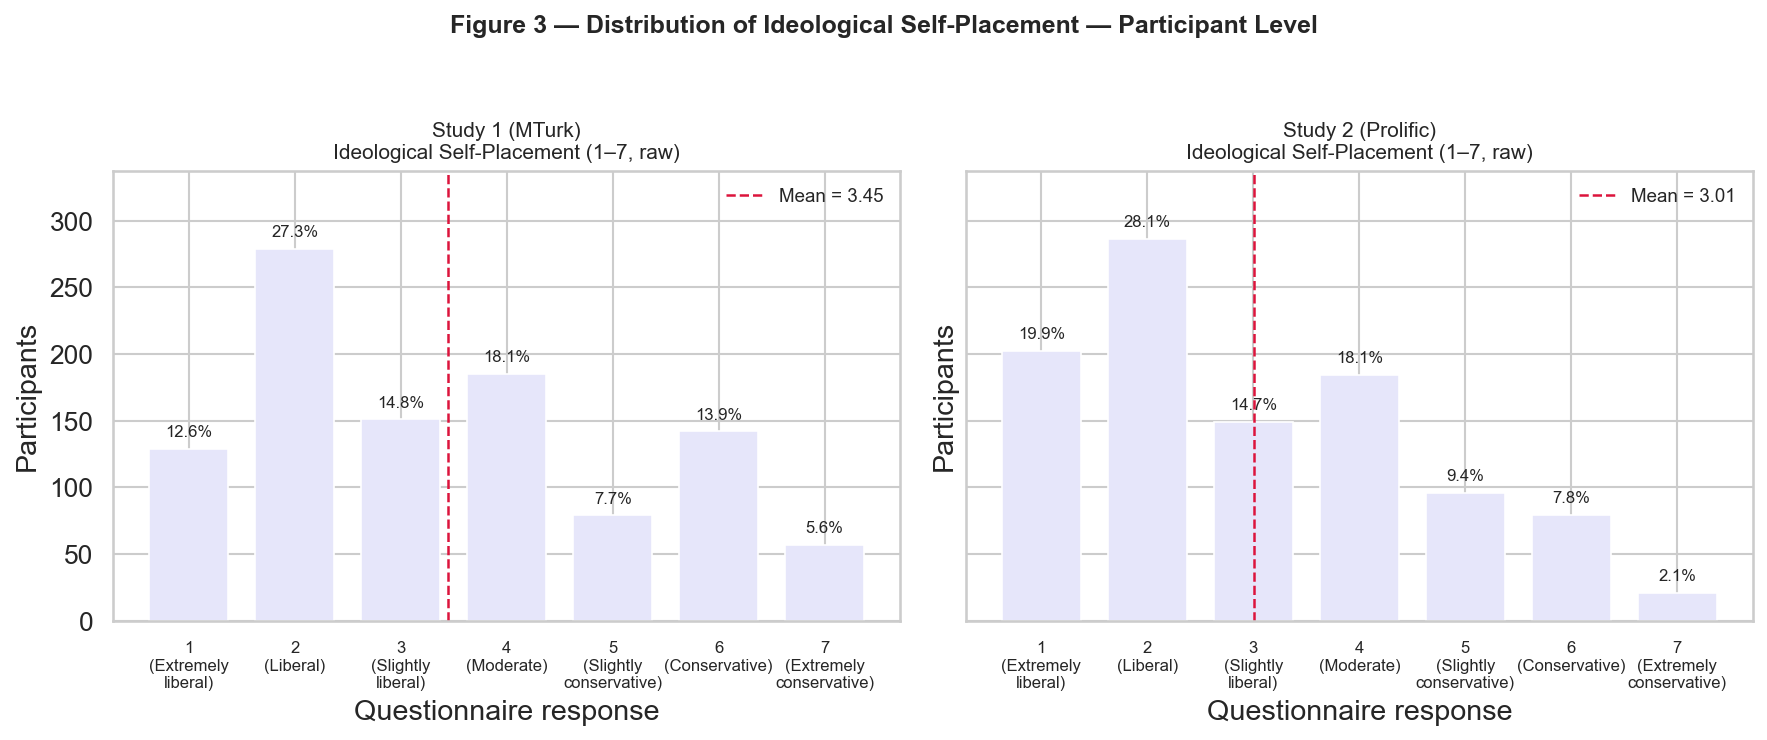

In [10]:
# Cell 8b: liberal — distribution plot (descriptive only)

# `liberal` is the primary self-placement ideology item collected on a 7-point
# ordered scale ranging from "Extremely liberal" to "Extremely conservative".

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

LIBERAL_LABELS = [
    '1\n(Extremely\nliberal)',
    '2\n(Liberal)',
    '3\n(Slightly\nliberal)',
    '4\n(Moderate)',
    '5\n(Slightly\nconservative)',
    '6\n(Conservative)',
    '7\n(Extremely\nconservative)',
]

def plot_liberal_distribution(demo, plabel, ax):
    s = demo['liberal'].dropna()
    
    # Count observed responses on the full questionnaire support.
    counts = s.value_counts().reindex(range(1, 8), fill_value=0)
    pct = counts / counts.sum() * 100

    bars = ax.bar(
        counts.index,
        counts.values,
        width=0.75,
        color='lavender',
        edgecolor='white',
        linewidth=0.8
    )

    # Mean line retained for a compact summary of location on the raw scale.
    ax.axvline(
        s.mean(),
        color='crimson',
        linestyle='--',
        linewidth=1.2,
        label=f'Mean = {s.mean():.2f}'
    )

    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(LIBERAL_LABELS, fontsize=8)
    ax.set_title(f'{plabel}\nIdeological Self-Placement (1–7, raw)', fontsize=10)
    ax.set_xlabel('Questionnaire response')
    ax.set_ylabel('Participants')
    ax.legend(fontsize=9, frameon=False)

    # Annotate percentages above bars to aid direct interpretation.
    ymax = counts.max()
    ax.set_ylim(0, ymax * 1.18)

    for bar, p in zip(bars, pct):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + ymax * 0.025,
            f'{p:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

for ax, (demo, plabel) in zip(
    axes,
    [(demo_mt, 'Study 1 (MTurk)'), (demo_pr, 'Study 2 (Prolific)')]
):
    plot_liberal_distribution(demo, plabel, ax)

plt.suptitle(
    'Figure 3 — Distribution of Ideological Self-Placement — Participant Level',
    fontsize=12,
    fontweight='bold',
    y=1.03
)
plt.tight_layout()

plt.savefig('outputs/figures/figure3_liberal_distribution.png', bbox_inches='tight')
plt.show()

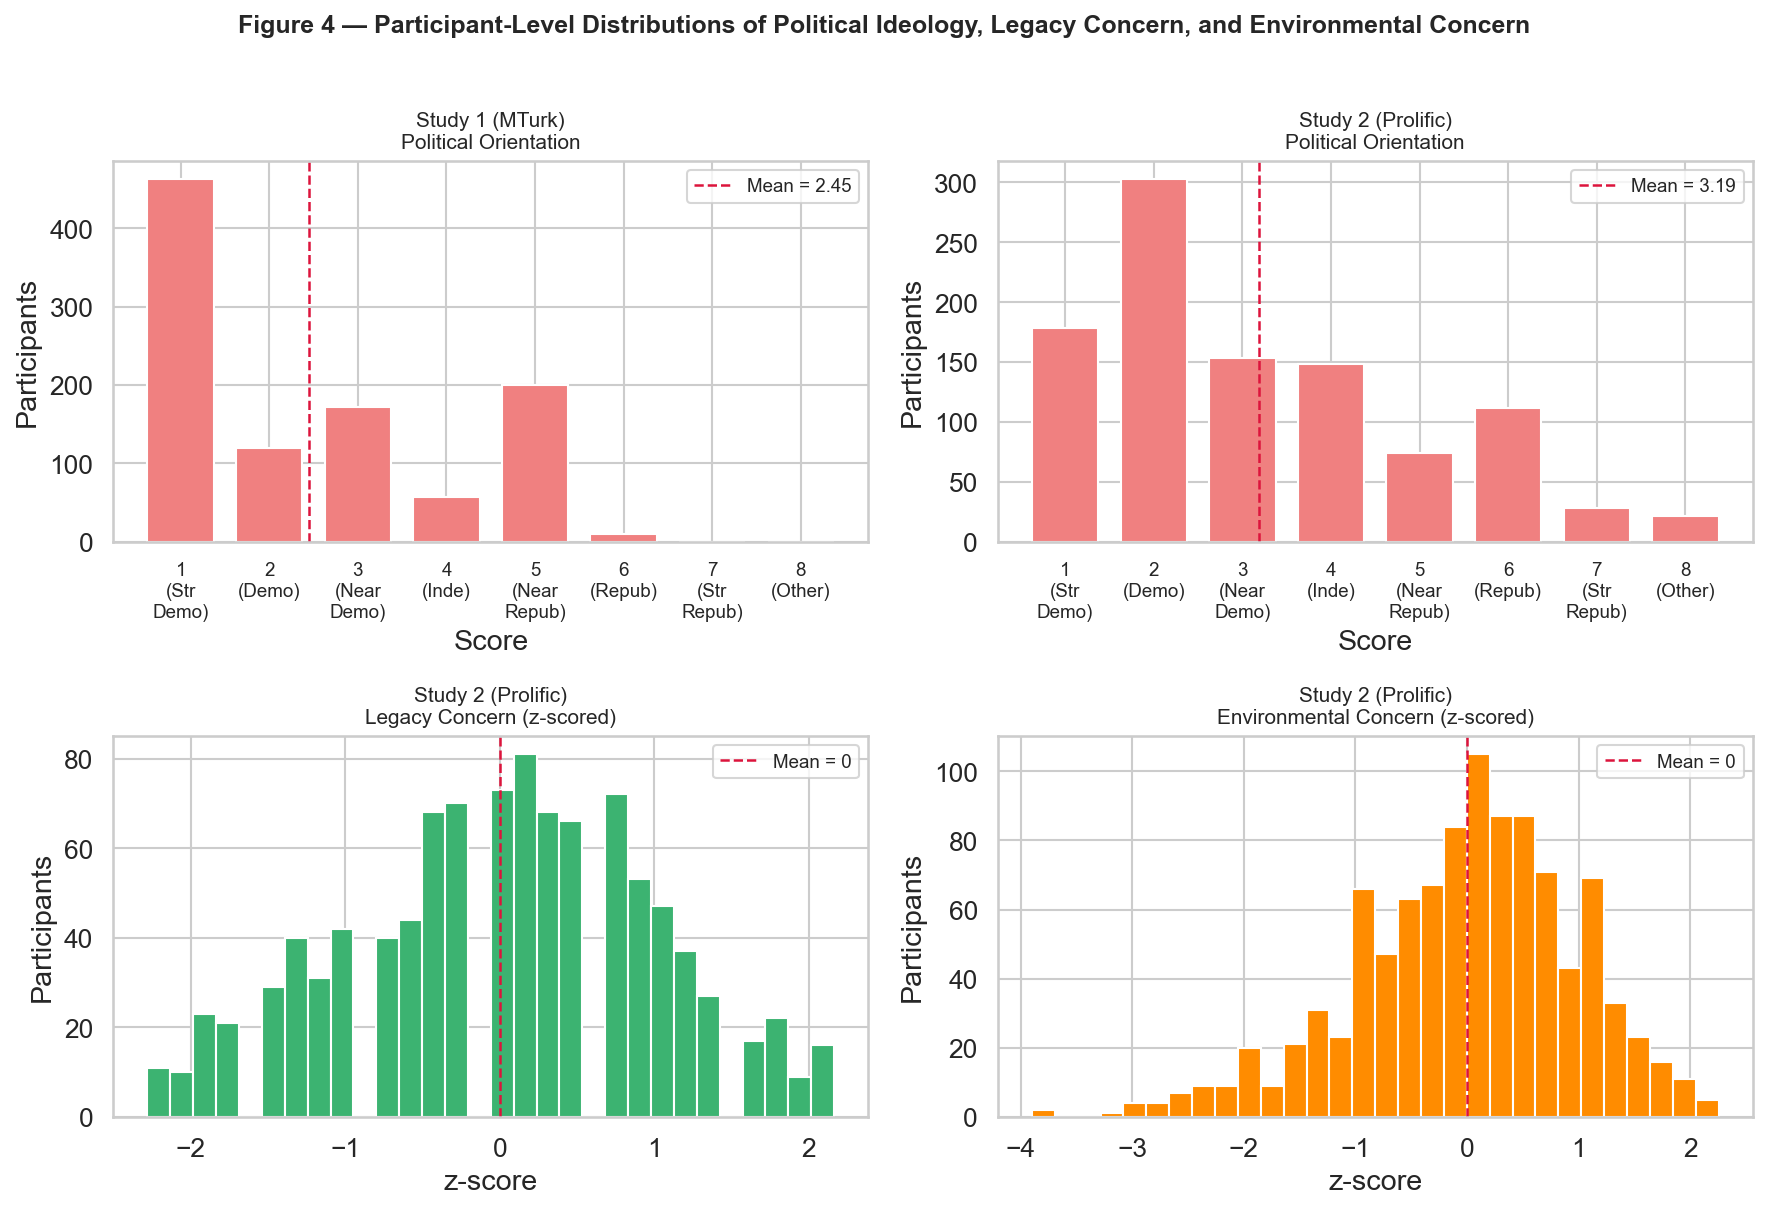

In [11]:
# Cell 8c: Moderator distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (demo, plabel) in zip(axes[0], [(demo_mt, 'Study 1 (MTurk)'), (demo_pr, 'Study 2 (Prolific)')]):
    pol = demo['political_orientation'].dropna()
    ax.hist(pol, bins=range(1, 10), align='left', rwidth=0.75, color='lightcoral', edgecolor='white')
    ax.set_xticks(range(1, 9))
    ax.set_xticklabels(['1\n(Str\nDemo)', '2\n(Demo)', '3\n(Near\nDemo)', '4\n(Inde)', '5\n(Near\nRepub)', '6\n(Repub)', '7\n(Str\nRepub)', '8\n(Other)'], fontsize=9)
    ax.set_title(f'{plabel}\nPolitical Orientation', fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('Participants')
    ax.axvline(pol.mean(), color='crimson', linestyle='--', linewidth=1.2, label=f'Mean = {pol.mean():.2f}')
    ax.legend(fontsize=9)

ax = axes[1, 0]
if 'legacy_z' in demo_pr.columns and demo_pr['legacy_z'].notna().any():
    lc = demo_pr['legacy_z'].dropna()
    ax.hist(lc, bins=30, color='mediumseagreen', edgecolor='white')
    ax.set_title('Study 2 (Prolific)\nLegacy Concern (z-scored)', fontsize=10)
    ax.set_xlabel('z-score'); ax.set_ylabel('Participants')
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1.2, label='Mean = 0')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'legacy_z\nnot available', ha='center', va='center', transform=ax.transAxes, fontsize=10)
    ax.set_title('Study 2 (Prolific) — Legacy Concern', fontsize=10)

ax = axes[1, 1]
if 'env_concern_z' in demo_pr.columns and demo_pr['env_concern_z'].notna().any():
    ec = demo_pr['env_concern_z'].dropna()
    ax.hist(ec, bins=30, color='darkorange', edgecolor='white')
    ax.set_title('Study 2 (Prolific)\nEnvironmental Concern (z-scored)', fontsize=10)
    ax.set_xlabel('z-score'); ax.set_ylabel('Participants')
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1.2, label='Mean = 0')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'env_concern_z\nnot available', ha='center', va='center', transform=ax.transAxes, fontsize=10)
    ax.set_title('Study 2 (Prolific) — Env. Concern', fontsize=10)

plt.suptitle('Figure 4 — Participant-Level Distributions of Political Ideology, Legacy Concern, and Environmental Concern', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/figure4_Participant-Level Distributions of Political Ideology, Legacy Concern, and Environmental Concern.png', dpi=200, bbox_inches='tight')
plt.show()

## 9 · Multilevel Data Structure

The primary model is a three-level structure — decision-rounds (L1) nested in participants (L2) nested in sessions (L3), with `sessioncode` as the top-level random-intercept grouping variable and a participant-level random intercept nested within it. Sessions are also the unit of treatment randomisation. The table below documents session counts and mean group size per study.

In [12]:
# Cell 9: Nesting-structure diagnostic
for label, df_r, demo in [('Study 1 (MTurk)', df_mt, demo_mt), ('Study 2 (Prolific)', df_pr, demo_pr)]:
    n_obs   = len(df_r)
    n_part  = df_r['participantcode'].nunique()
    n_sess  = df_r['sessioncode'].nunique()
    obs_per = df_r.groupby('participantcode').size()
    part_per_sess = demo.groupby('sessioncode')['participantcode'].nunique()

    print(f'\n{label}')
    print(f'  L1 observations (rounds):        {n_obs:,}')
    print(f'  L2 participants:                 {n_part:,}')
    print(f'  L3 sessions (randomisation unit):{n_sess:,}')
    print(f'  Rounds per participant — mean:   {obs_per.mean():.1f}  min: {obs_per.min()}  max: {obs_per.max()}')
    print(f'  Participants per session — mean: {part_per_sess.mean():.1f}  min: {part_per_sess.min()}  max: {part_per_sess.max()}')


Study 1 (MTurk)
  L1 observations (rounds):        10,220
  L2 participants:                 1,022
  L3 sessions (randomisation unit):308
  Rounds per participant — mean:   10.0  min: 10  max: 10
  Participants per session — mean: 3.3  min: 1  max: 4

Study 2 (Prolific)
  L1 observations (rounds):        10,170
  L2 participants:                 1,017
  L3 sessions (randomisation unit):288
  Rounds per participant — mean:   10.0  min: 10  max: 10
  Participants per session — mean: 3.5  min: 1  max: 4


## 10 · Prolific-Only Electoral Variables

`voted_trump_2020` and `voted_rep_2024` are collected only in Study 2 and serve as binary vote-choice proxies in robustness runs R2 and R3 (Notebook 05), not as moderators in the primary analysis. `voted_trump_2020` assigns `NaN` to non-voters by design (Notebook 01); this is not incidental missingness and those cases are excluded from R2 specifically, not from the analytic sample generally. `voted_rep_2024` maps all six candidate options to a binary with no exclusions.

In [13]:
# Cell 10: Prolific electoral variable descriptives
if 'voted_trump_2020' in demo_pr.columns:
    v2020 = demo_pr['voted_trump_2020']
    n_valid = v2020.notna().sum()
    n_trump = (v2020 == 1).sum()
    n_biden = (v2020 == 0).sum()
    n_excl  = v2020.isna().sum()
    print('voted_trump_2020 (Prolific, robustness R2):')
    print(f'  Voted Trump (=1): {n_trump:,} ({n_trump/n_valid*100:.1f}% of voters)')
    print(f'  Voted Biden (=0): {n_biden:,} ({n_biden/n_valid*100:.1f}% of voters)')
    print(f'  Non-voters (NaN, excluded from R2 only): {n_excl:,}')

if 'voted_rep_2024' in demo_pr.columns:
    v2024 = demo_pr['voted_rep_2024']
    n_rep = (v2024 == 1).sum()
    n_dem = (v2024 == 0).sum()
    print('\nvoted_rep_2024 (Prolific, robustness R3):')
    print(f'  Voted Republican (=1): {n_rep:,} ({n_rep/len(demo_pr)*100:.1f}%)')
    print(f'  Voted Democrat   (=0): {n_dem:,} ({n_dem/len(demo_pr)*100:.1f}%)')
    print(f'  NaN: {v2024.isna().sum():,}')

voted_trump_2020 (Prolific, robustness R2):
  Voted Trump (=1): 184 (22.8% of voters)
  Voted Biden (=0): 622 (77.2% of voters)
  Non-voters (NaN, excluded from R2 only): 211

voted_rep_2024 (Prolific, robustness R3):
  Voted Republican (=1): 274 (26.9%)
  Voted Democrat   (=0): 743 (73.1%)
  NaN: 0


## 11 · Missingness Audit

Two complementary checks. **11a** reloads the three-stage attrition audit produced in Notebook 01 (raw export → after pre-registered exclusions → analytic sample via listwise deletion). **11b** verifies, on the analytic sample actually loaded into this notebook, that no unexpected missingness remains on any modelling covariate — this is a completeness check on the data as loaded here, not a re-derivation of Notebook 01's audit.

In [14]:
# Cell 11a: Reload three-stage attrition audit from Notebook 01
try:
    audit = pd.read_csv('outputs/tables/missingness_audit.csv', index_col=0)
    print('Missingness Audit:')
    print(audit.to_string())
except FileNotFoundError:
    print('Missingness audit not found — run Notebook 01 first.')

Missingness Audit:
                           MTurk Prolific
Raw rows                   11389    10751
Raw participants            1167     1093
After pre-reg excl (rows)  10330    10170
After pre-reg excl (pts)    1033     1017
Analytic sample (rows)     10220    10170
Analytic sample (pts)       1022     1017
Dropped — pre-reg (rows)    1059      581
Dropped — listwise (rows)    110        0
Total dropped (%)          10.3%     5.4%


In [15]:
# Cell 11b: Analytic-sample completeness check, participant level
ANALYSIS_VARS_MT = ['political_orientation', 'party_id_z', 'age', 'gender', 'ethnic_min', 'education']
ANALYSIS_VARS_PR = ANALYSIS_VARS_MT + ['legacy_z', 'env_concern_z', 'voted_trump_2020', 'voted_rep_2024']

for label, demo, avars in [('Study 1 (MTurk)', demo_mt, ANALYSIS_VARS_MT),
                            ('Study 2 (Prolific)', demo_pr, ANALYSIS_VARS_PR)]:
    print(f'\n{label} — Missing values (participant level, N = {len(demo):,})')
    for v in avars:
        if v in demo.columns:
            miss = demo[v].isna().sum()
            pct  = miss / len(demo) * 100
            note = '  (non-voters, assigned by design — see Section 10)' if v == 'voted_trump_2020' and miss > 0 else ''
            print(f'  {v:<25}  {miss:>4} missing  ({pct:.1f}%){note}')
        else:
            print(f'  {v:<25}  [column not present]')


Study 1 (MTurk) — Missing values (participant level, N = 1,022)
  political_orientation         0 missing  (0.0%)
  party_id_z                    0 missing  (0.0%)
  age                           0 missing  (0.0%)
  gender                        0 missing  (0.0%)
  ethnic_min                    0 missing  (0.0%)
  education                     0 missing  (0.0%)

Study 2 (Prolific) — Missing values (participant level, N = 1,017)
  political_orientation         0 missing  (0.0%)
  party_id_z                    0 missing  (0.0%)
  age                           0 missing  (0.0%)
  gender                        0 missing  (0.0%)
  ethnic_min                    0 missing  (0.0%)
  education                     0 missing  (0.0%)
  legacy_z                      0 missing  (0.0%)
  env_concern_z                 0 missing  (0.0%)
  voted_trump_2020            211 missing  (20.7%)  (non-voters, assigned by design — see Section 10)
  voted_rep_2024                0 missing  (0.0%)


## 12 · Export

Derived tables (Sections 3–8, 10) are written to `outputs/tables/` and figures to `outputs/figures/` inline as each is produced. The participant-level analytic frames (with treatment label and `extract_green_choice_rate` attached) are additionally exported here for any downstream descriptive queries that don't require the round-level structure; the multilevel models operate directly on the round-level CSVs from Notebook 01, not on these files.

In [16]:
# Cell 12: Export participant-level frames
demo_mt.to_csv('data/participant_level_mturk.csv', index=False)
demo_pr.to_csv('data/participant_level_prolific.csv', index=False)

print('Exported:')
print('  data/participant_level_mturk.csv')
print('  data/participant_level_prolific.csv')
print()
print('Table/figure outputs written to outputs/tables/ and outputs/figures/ throughout this notebook.')
print('Notebook 02 complete.')

Exported:
  data/participant_level_mturk.csv
  data/participant_level_prolific.csv

Table/figure outputs written to outputs/tables/ and outputs/figures/ throughout this notebook.
Notebook 02 complete.
